In [1]:
# setting root at top

import sys
from pathlib import Path

sys.path.append(str(Path("..").resolve()))

# NormModel 64x64 Image and 4 Conv Blocks
# Using OverSampled high-alert and 0.0075 Learning Rate

### Import libraries
* `torch`
* `datasets` and `transforms` from `torchvision` for data Loading.
* `DataLoader` and `WeightedRandomSampler` from `torch.utils.data` for Batching and using data in model.
* `NormModel` from `architectures.NormModel.py`
* `pandas` as `pd`
* `matplotlib.pyplot` as `plt`
* `seaborn` as sns
* `trainer` from `modules.TrainTest`
* `oversampler` from `modules.OverSampler`

In [2]:
# training and architecture
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, WeightedRandomSampler
from architectures.NormModel import NormModel

# visualization
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#trainer and tester modules
from modules.TrainTest import trainer
from modules.OverSampler import oversampler

### Load datasets for training
* load 64x64 images
* load from `../dataset/final-dataset/train`
* convert to tensor
* make batch_size = 32

In [3]:
train_transform = transforms.Compose([
        transforms.Resize((64, 64)),
        transforms.ToTensor()
    ]
)

train_dataset = datasets.ImageFolder(
    root="../dataset/final-dataset/train",
    transform=train_transform
)

sampler = oversampler(
    dataset=train_dataset,
    oversample_rate= 8
)


In [4]:

train_dataloader = DataLoader(
    dataset=train_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=4,
    pin_memory=True,
    persistent_workers=True,
    sampler = sampler
)

### Load datasets for training
* load 64x64 images
* load from `../dataset/final-dataset/train`
* convert to tensor
* make batch_size = 32

In [5]:
valid_transform = transforms.Compose([
        transforms.Resize((64, 64)),
        transforms.ToTensor()
    ]
)

valid_dataset = datasets.ImageFolder(
    root="../dataset/final-dataset/valid",
    transform=valid_transform
)

valid_dataloader = DataLoader(
    dataset=valid_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=4,
    pin_memory=True,
    persistent_workers=True
)

### Use Model for training
Initialize model using 
* `conv_layers = 4`, 
* `initial_output_channel = 8` 
* `initial_image_size = 64`

In [6]:
model = NormModel(conv_layers=4, initial_output_channel=8, initial_image_size=64).to("cuda")

In [7]:
metrics = trainer(
    model=model,
    train_dataloader=train_dataloader,
    test_dataloader=valid_dataloader,
    epoch=50,
    lr=0.005,
    print_on=2,
    save_dir="../models/norm_img64_c4_lr_0.005_os/",
    save_checkpoints=2,
    checkpoint_name="norm_64x64_train_0_",
    early_stop_patience = 20,
    min_delta = 0.01
)

Epoch 2/50 | Train Loss: 0.6820 | Valid Loss: 0.8094
Epoch 4/50 | Train Loss: 0.4890 | Valid Loss: 0.7295
Epoch 6/50 | Train Loss: 0.4148 | Valid Loss: 0.7042
Epoch 8/50 | Train Loss: 0.3733 | Valid Loss: 0.6751
Epoch 10/50 | Train Loss: 0.3468 | Valid Loss: 0.6946
Epoch 12/50 | Train Loss: 0.3210 | Valid Loss: 0.6906
Epoch 14/50 | Train Loss: 0.3039 | Valid Loss: 0.7001
Epoch 16/50 | Train Loss: 0.2889 | Valid Loss: 0.7183
Epoch 18/50 | Train Loss: 0.2818 | Valid Loss: 0.7545
Epoch 20/50 | Train Loss: 0.2699 | Valid Loss: 0.7154
Epoch 22/50 | Train Loss: 0.2669 | Valid Loss: 0.7276
Epoch 24/50 | Train Loss: 0.2546 | Valid Loss: 0.7123
Epoch 26/50 | Train Loss: 0.2518 | Valid Loss: 0.7345
Early stopping at epoch 28 | No improvement for 20 epochs


## Visualize

Convert metrics to a pd.DataFrame and add epoch column for visualization.

In [8]:
metrics = pd.DataFrame(metrics)
epochs = [i+1 for i  in range(len(metrics))]
metrics["epoch"] = epochs

In [9]:
metrics

,epoch,training_loss,training_accuracy,training_precision,training_recall,training_f1,valid_loss,valid_accuracy,valid_precision,valid_recall,valid_f1
0,1,0.900173,0.564276,0.562521,0.564203,0.562990,0.887235,0.551885,0.499098,0.538514,0.459058
1,2,0.681998,0.695298,0.692597,0.695223,0.693459,0.809431,0.625159,0.558236,0.598561,0.544177
2,3,0.563826,0.751434,0.749264,0.751359,0.749935,0.776354,0.658196,0.572596,0.609798,0.570456
3,4,0.489040,0.785109,0.782584,0.784139,0.783047,0.729502,0.684879,0.603741,0.620162,0.599445
4,5,0.447155,0.803985,0.802705,0.804114,0.803229,0.715866,0.686997,0.616399,0.618235,0.604785
5,6,0.414816,0.819331,0.818994,0.820122,0.819400,0.704231,0.685303,0.603227,0.599723,0.591641
6,7,0.392023,0.827960,0.827065,0.828089,0.827452,0.795318,0.651842,0.609107,0.579088,0.562496
7,8,0.373309,0.837842,0.837283,0.838121,0.837590,0.675083,0.734435,0.634813,0.638124,0.635706
8,9,0.355127,0.846858,0.846144,0.846820,0.846385,0.739299,0.688268,0.609131,0.583802,0.580869
9,10,0.346814,0.850467,0.849920,0.850501,0.850124,0.694591,0.719187,0.624016,0.626374,0.621415


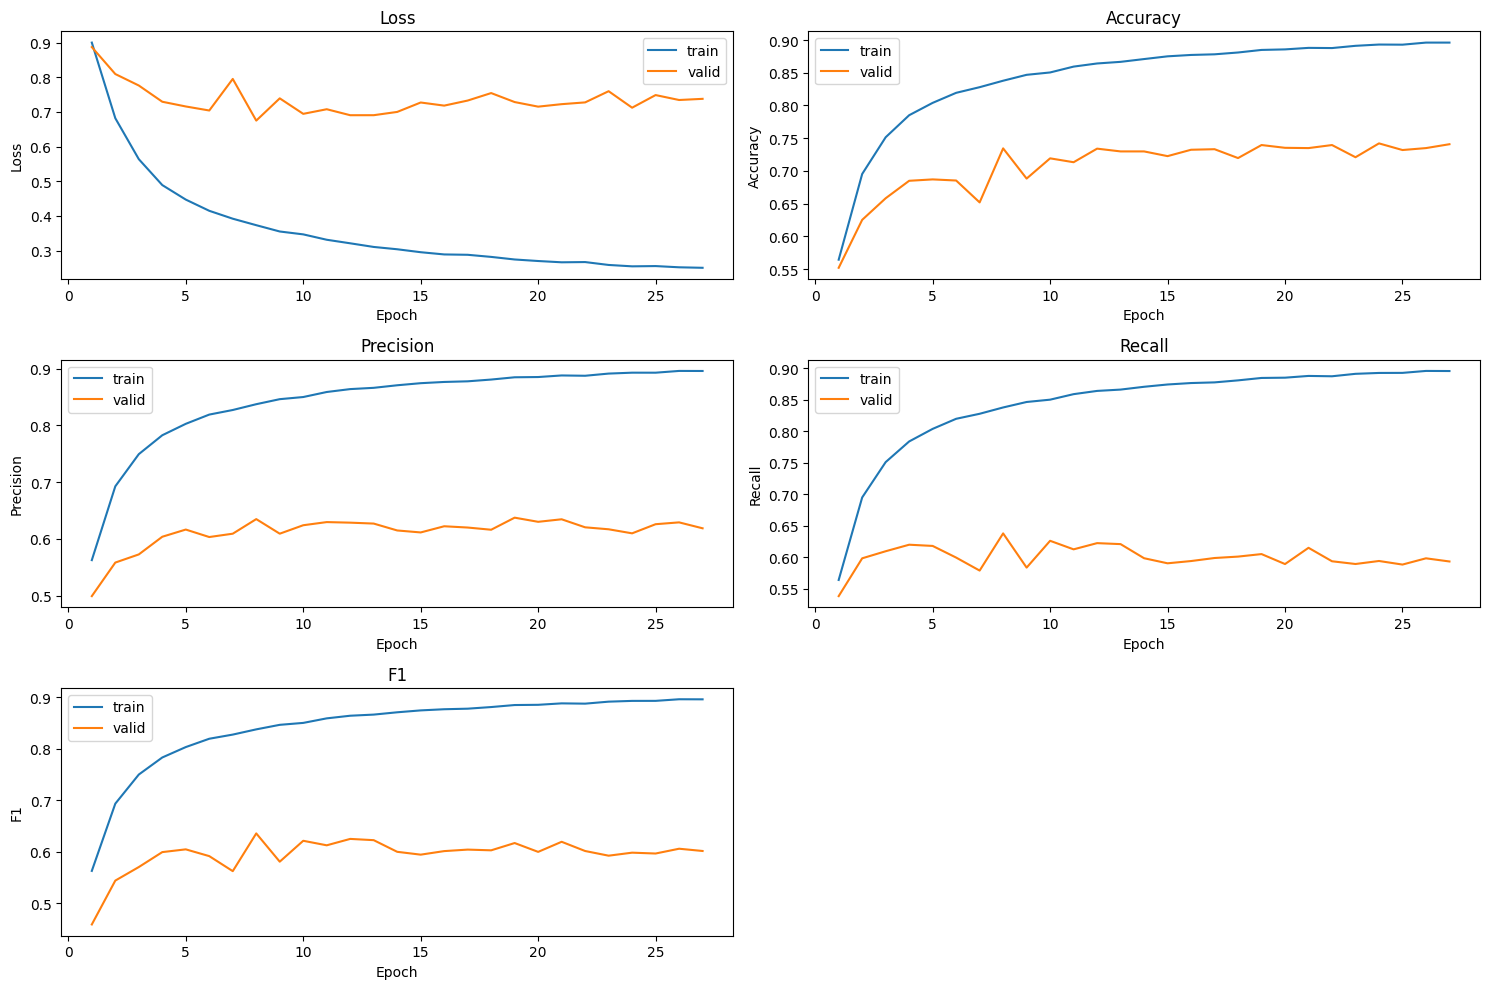

In [10]:
fig, axes = plt.subplots(3, 2, figsize=(15, 10))
axes = axes.flatten()

to_viz = [
    "loss",
    "accuracy",
    "precision",
    "recall",
    "f1"
]

for i, metric in enumerate(to_viz):

    ax = axes[i]

    sns.lineplot(
        data=metrics,
        x="epoch",
        y=f"training_{metric}",
        ax=ax,
        label="train"
    )

    sns.lineplot(
        data=metrics,
        x="epoch",
        y=f"valid_{metric}",
        ax=ax,
        label="valid"
    )

    ax.set_title(metric.capitalize())
    ax.set_xlabel("Epoch")
    ax.set_ylabel(metric.capitalize())

# Hide unused subplot (6th slot)
axes[-1].axis("off")

plt.tight_layout()
plt.show()